29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape:  (60000, 28, 28)
y_train shape:  (60000,)
X_test shape:  (10000, 28, 28)


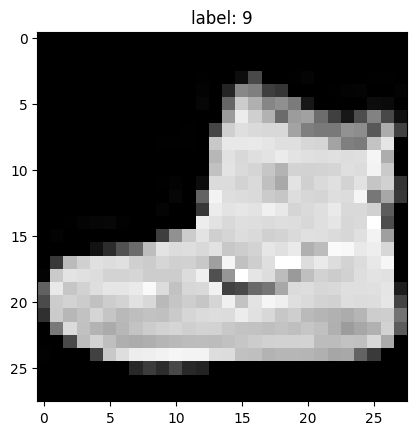

0.0 1.0
(60000, 784)
(10000, 784)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()
print("X_train shape: ",X_train.shape)
print("y_train shape: ",y_train.shape)
print("X_test shape: ",X_test.shape)
plt.imshow(X_train[0],cmap='gray')
plt.title(f"label: {y_train[0]}")
plt.show()
X_train_scaled=X_train/255.0
X_test_scaled=X_test/255.0
print(X_train_scaled.min(),X_train_scaled.max())
X_train_flat=X_train_scaled.reshape(60000,28*28)
X_test_flat=X_test_scaled.reshape(10000,28*28)
print(X_train_flat.shape)
print(X_test_flat.shape)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
tf.random.set_seed(42)
model=Sequential()
model.add(Dense(units=128,activation='relu',input_shape=(784,)))
model.add(Dense(units=64,activation='relu'))
model.add(Dense(units=10,activation='softmax'))
model.summary()



In [4]:

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',metrics=['accuracy']
)
history=model.fit(
    X_train_flat,y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8186 - loss: 0.5043 - val_accuracy: 0.8518 - val_loss: 0.3959
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8642 - loss: 0.3730 - val_accuracy: 0.8673 - val_loss: 0.3595
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8768 - loss: 0.3340 - val_accuracy: 0.8683 - val_loss: 0.3586
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8854 - loss: 0.3107 - val_accuracy: 0.8713 - val_loss: 0.3531
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8924 - loss: 0.2903 - val_accuracy: 0.8700 - val_loss: 0.3535
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8973 - loss: 0.2751 - val_accuracy: 0.8702 - val_loss: 0.3567
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9024 - loss: 0.2625 - val_accuracy: 0.8723 - val_loss: 0.3598


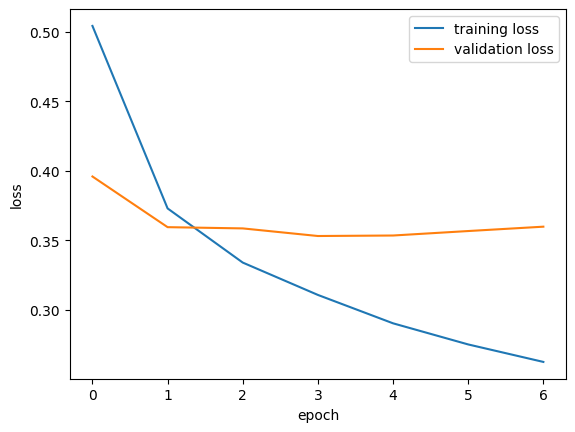

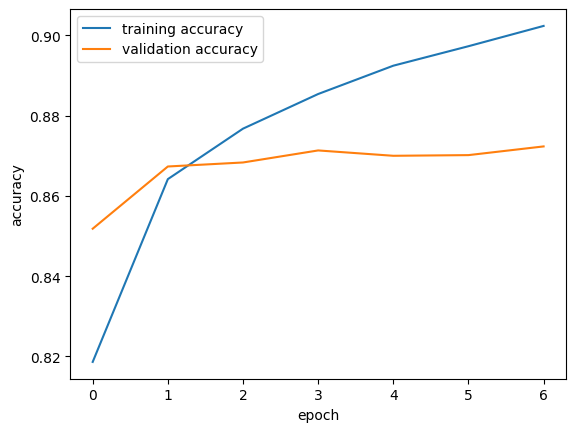

In [5]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)
print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

Test accuracy: 0.8633000254631042
Test loss: 0.38703715801239014


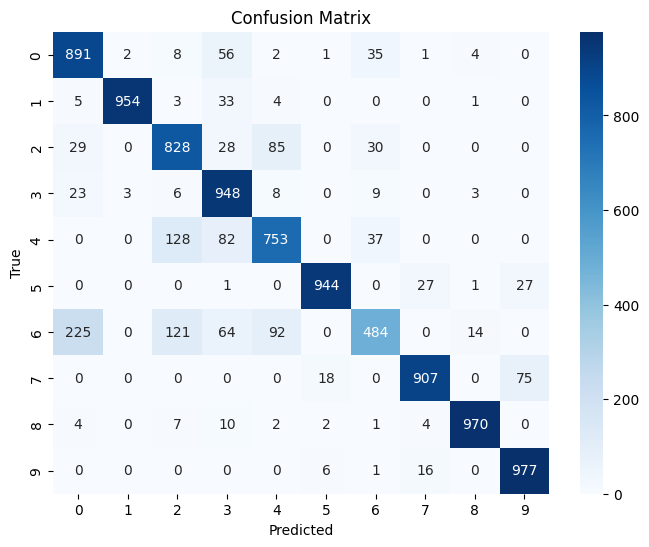

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred_probs=model.predict(X_test_flat,verbose=0)
y_pred=np.argmax(y_pred_probs,axis=1)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

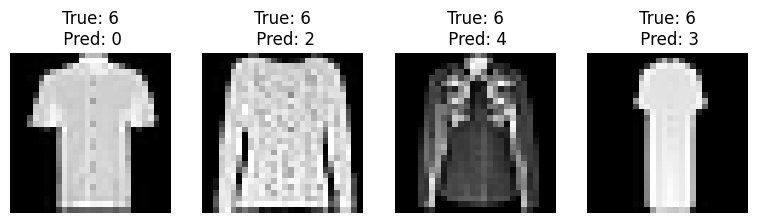

In [8]:
shirt_errors = np.where((y_test == 6) & (y_pred!=6))[0]
plt.figure(figsize=(12,4))
for i,idx in enumerate(shirt_errors[:4]):
  plt.subplot(1,5,i+1)
  plt.imshow(X_test[idx],cmap='gray')
  plt.title(f"True: 6\n Pred: {y_pred[idx]}")
  plt.axis('off')
plt.show()

In [10]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
per_class_accuracy=cm.diagonal()/cm.sum(axis=1)
for name,acc in zip(class_names,per_class_accuracy):
  print(f"{name:15s}: {acc:.3f}")

T-shirt/top    : 0.891
Trouser        : 0.954
Pullover       : 0.828
Dress          : 0.948
Coat           : 0.753
Sandal         : 0.944
Shirt          : 0.484
Sneaker        : 0.907
Bag            : 0.970
Ankle boot     : 0.977
